# SCT_DS_3 - Bank Marketing Decision Tree Classification

## Objective

The objective of this project is to build a Decision Tree Classifier to predict whether a customer will subscribe to a term deposit based on demographic and behavioral attributes.

The project uses the Bank Marketing Dataset and applies machine learning techniques to classify customer responses and evaluate prediction performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [6]:
df = pd.read_csv('bank-full[1].csv', sep=';')

In [7]:
df.sample(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
18945,41,management,married,tertiary,no,651,no,no,cellular,4,aug,104,1,-1,0,unknown,no
28140,60,technician,married,secondary,no,2041,no,no,telephone,29,jan,123,1,185,7,failure,no
20736,31,entrepreneur,single,tertiary,yes,-405,yes,yes,cellular,13,aug,703,2,-1,0,unknown,yes
8822,29,blue-collar,married,secondary,no,-8,yes,yes,unknown,4,jun,433,2,-1,0,unknown,no
4160,49,blue-collar,married,primary,no,284,yes,no,unknown,19,may,81,1,-1,0,unknown,no


In [8]:
df.shape

(45211, 17)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


## Data Understanding

The dataset contains demographic, financial, and campaign-related information about bank customers. The target variable (`y`) indicates whether a customer subscribed to a term deposit.

In [11]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


/tmp/ipykernel_5234/3429472563.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='pastel')


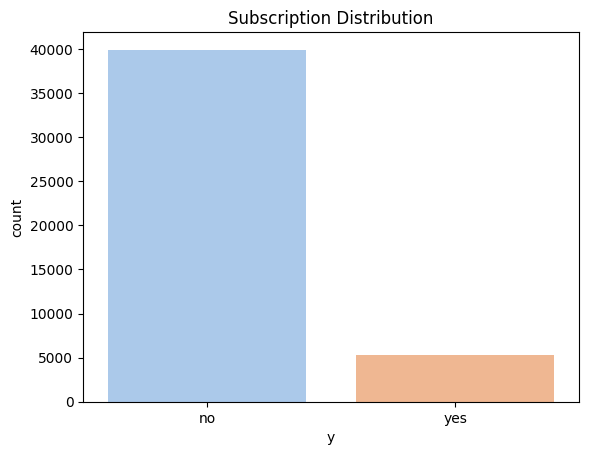

In [12]:
sns.countplot(x='y', data=df, palette='pastel')
plt.title('Subscription Distribution')
plt.show()

Observation

Most customers did not subscribe to the term deposit, while a smaller proportion accepted the offer.

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [14]:
X = df.drop('y', axis=1)
y = df['y']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8935087913303107


Observation

The Decision Tree model achieved a good classification accuracy, indicating its effectiveness in predicting customer subscription behavior.

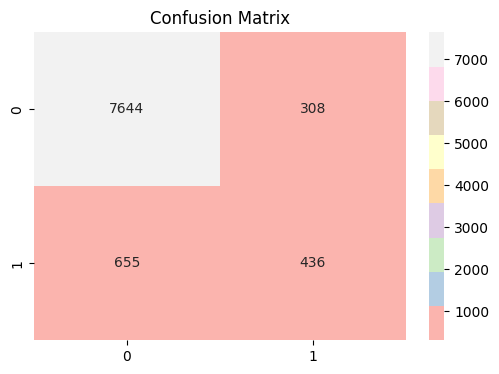

In [19]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Pastel1'
)

plt.title('Confusion Matrix')
plt.show()

Observation

The confusion matrix shows the number of correct and incorrect predictions made by the model for each class.

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.59      0.40      0.48      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.88      9043



Observation

Precision, recall, and F1-score provide a comprehensive evaluation of model performance.

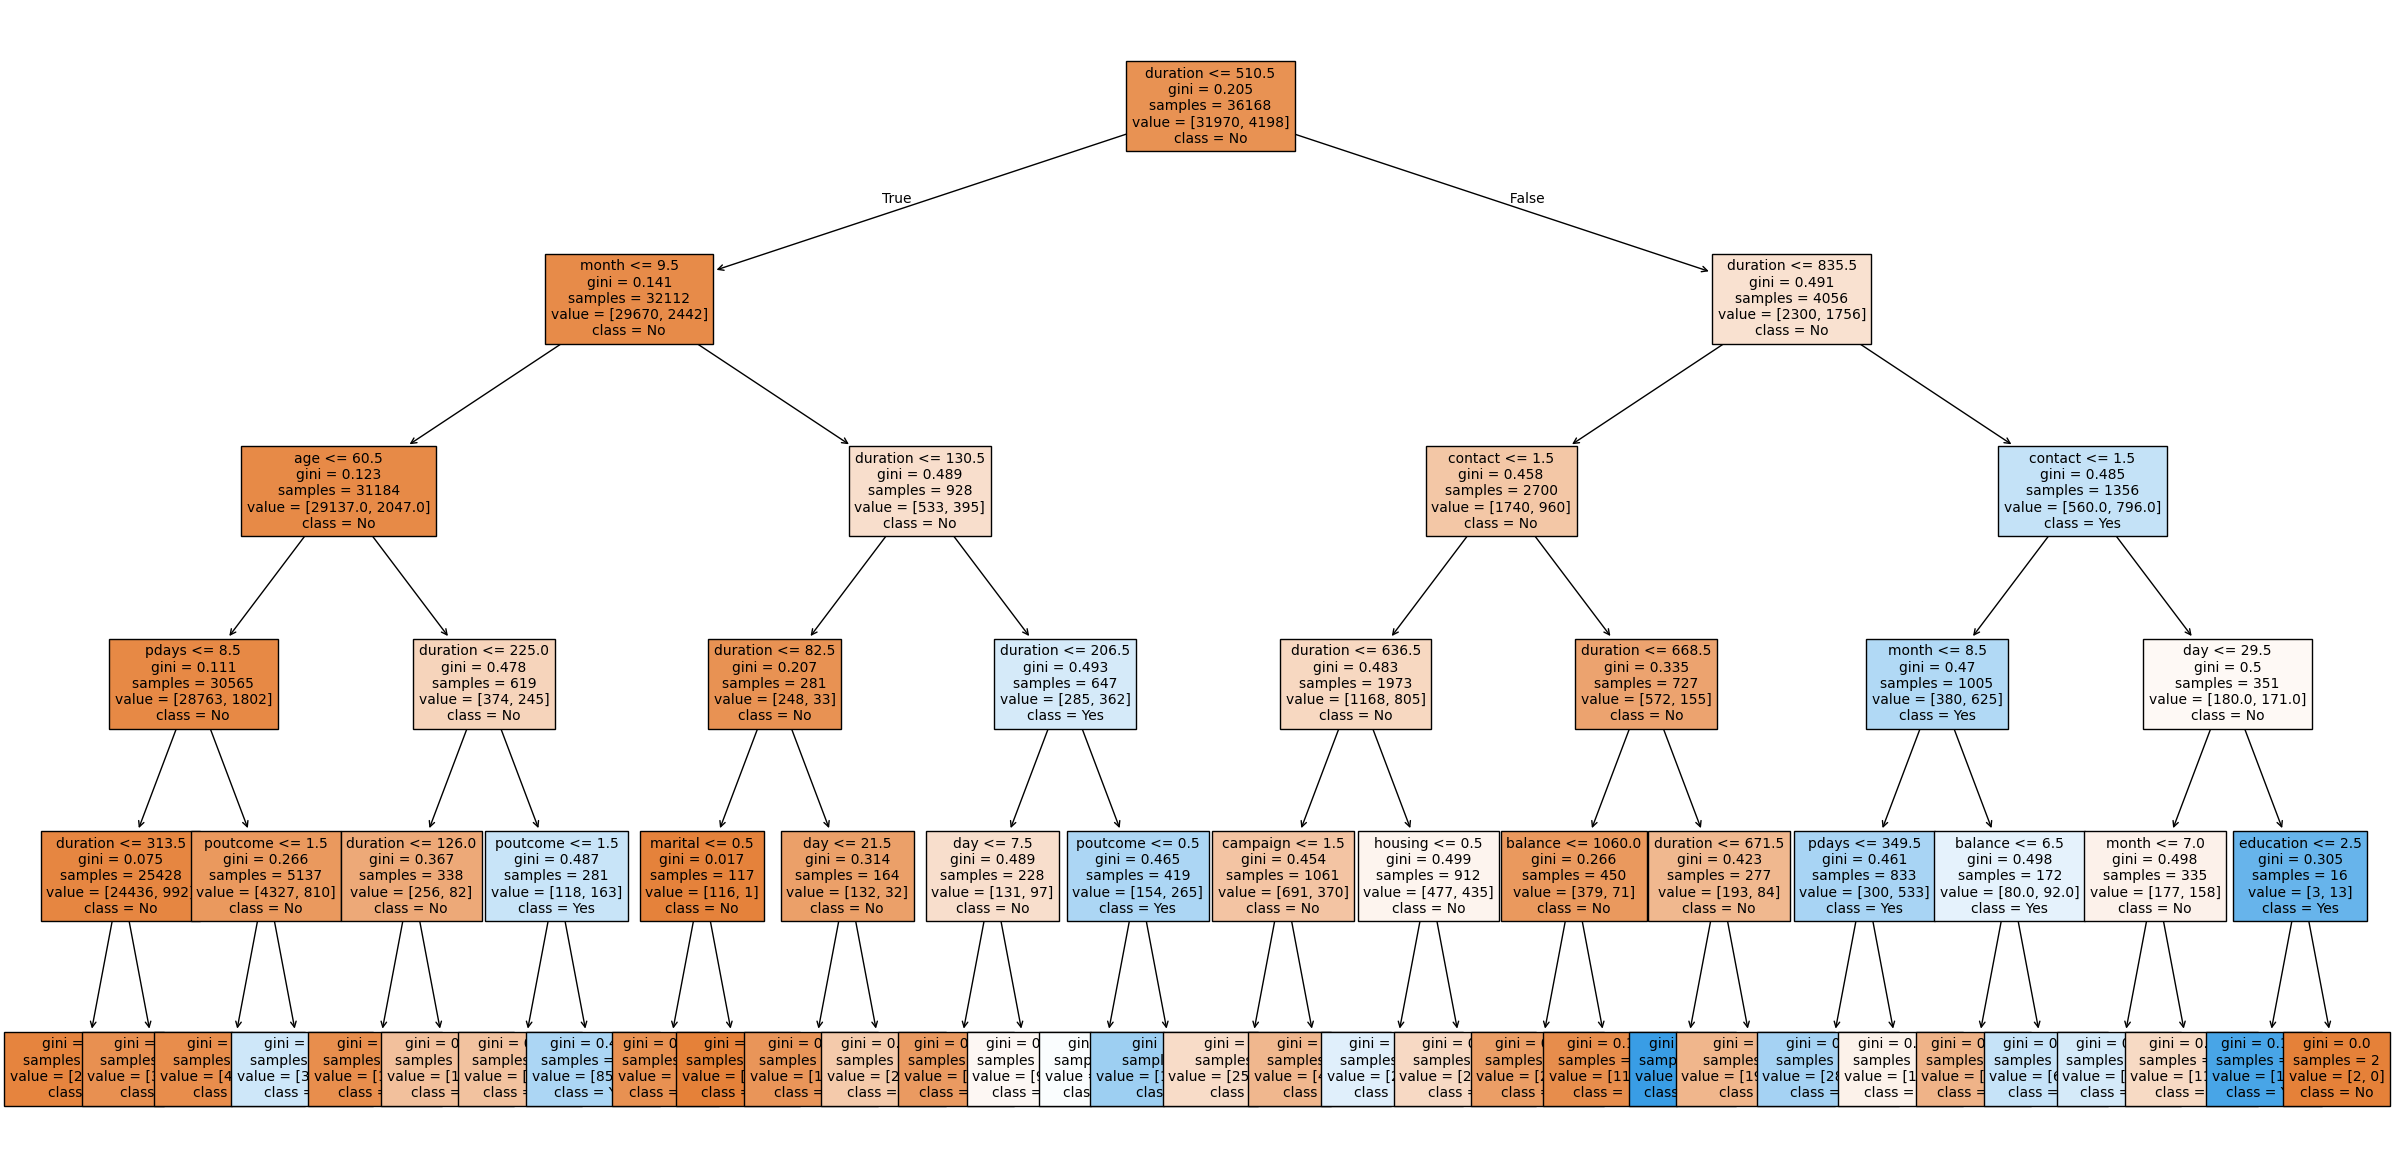

In [22]:
plt.figure(figsize=(30,15))

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    fontsize=10
)

plt.show()

Observation

The decision tree visualization illustrates how the model classifies customers based on demographic and behavioral attributes. Each node represents a decision rule, while the branches show the possible outcomes of that rule. The tree highlights the most influential features used for prediction and demonstrates how customer characteristics contribute to subscription decisions.

Observation

The Decision Tree Classifier achieved an accuracy of 89%, indicating strong predictive performance on the test dataset. This suggests that customer demographic and behavioral attributes provide valuable information for predicting whether a customer will subscribe to a term deposit. The model was able to correctly classify the majority of customer responses.

## Conclusion

A Decision Tree Classifier was developed to predict whether a customer would subscribe to a term deposit using demographic and behavioral information from the Bank Marketing Dataset.

The model achieved an accuracy of 89%, indicating strong classification performance. The decision tree visualization provided interpretable decision rules and highlighted important customer attributes influencing subscription decisions.

The results demonstrate how machine learning can support data-driven marketing strategies and help organizations identify customers who are more likely to respond positively to campaigns.